<a href="https://colab.research.google.com/github/bforoura/GENAI26/blob/main/Module5/ReACT_Agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ReACT Agent: A Simulation**


* This notebook is a **simulation**.

* To simplify the explanation of agentic workflows, we are using "**Mocked Tools**", i.e., Google Search and calculator.

* No real external APIs like Google Search or a WolframAlpha engine are actually called.

* This allows us to focus entirely on how **LangGraph** manages the state and logic flow.

  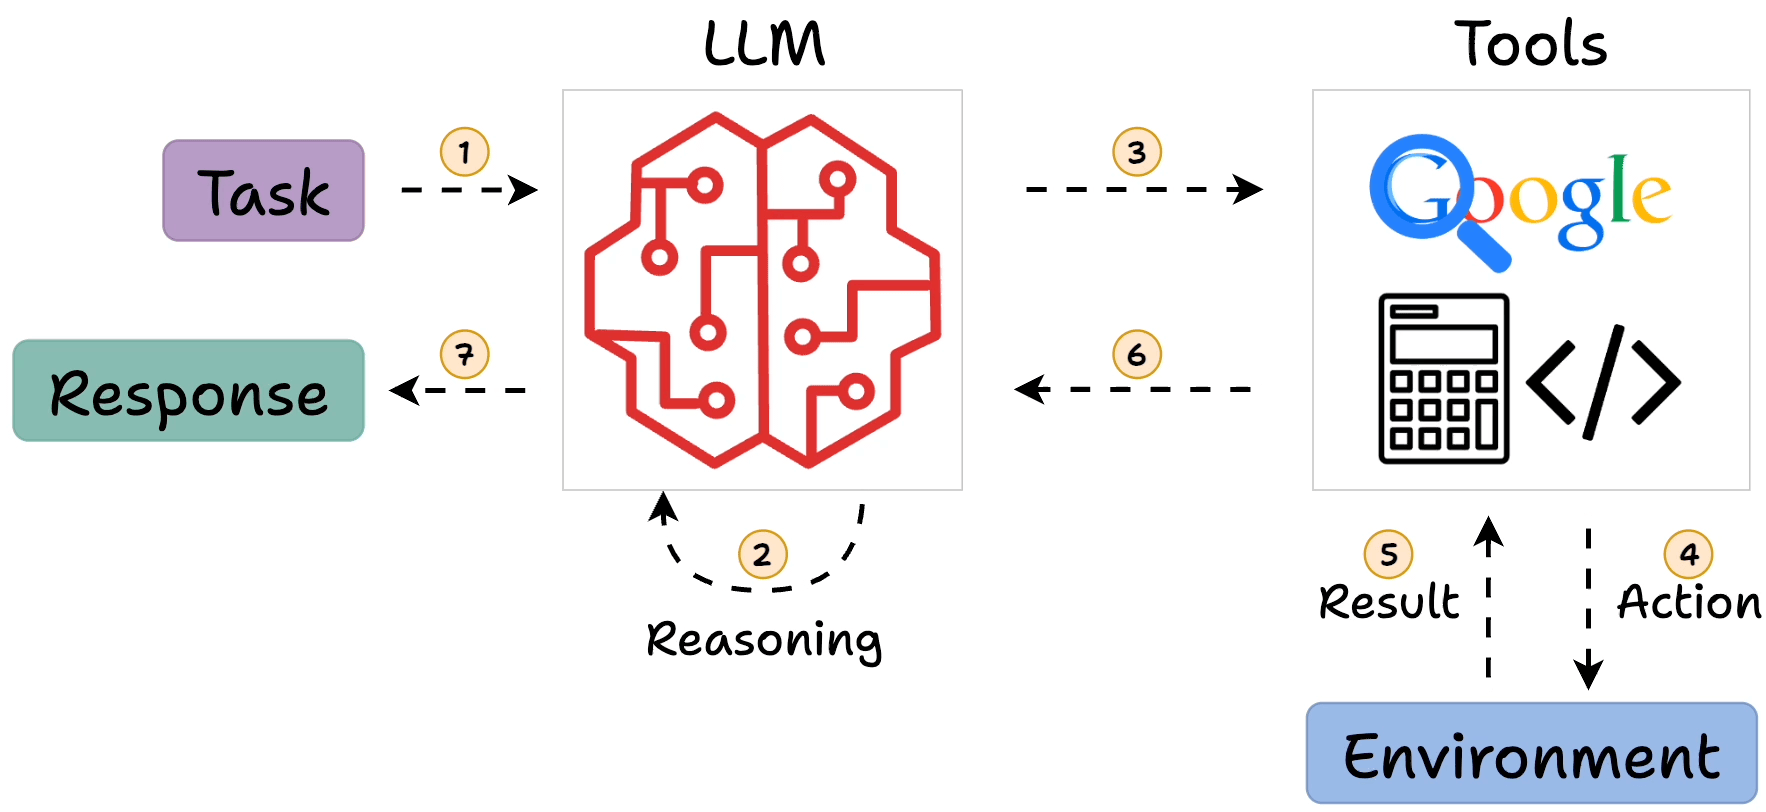

In [1]:
# Install necessary libraries for Graph support
!pip install -U -q langchain-google-genai langgraph


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.9/160.9 kB 2.5 MB/s eta 0:00:00


In [12]:
import os
import math
from google.colab import userdata
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.tools import tool
from langgraph.graph import MessagesState, StateGraph, START, END
from langgraph.prebuilt import ToolNode


# Authentication and Model
# Using Gemini 2.0 Flash (stable for 2026) or your specified 2.5-flash
os.environ["GOOGLE_API_KEY"] = userdata.get('GOOGLE_API_KEY')
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)


# **Tool Definitions**

* Here, we define the "**capabilities**" of our agent.

* By using the **@tool decorator**, we automatically generate a JSON schema that tells the LLM exactly when and how to call these functions.


  1. **Google Search**: A mocked tool that provides a consistent "2026 reality" for the agent, overriding its internal pre-training data.

  2. **Calculator**: A utility that evaluates mathematical expressions, allowing the agent to perform precise calculations that LLMs often struggle with natively.

----
# **Graph Logic: The "Brain" and the "Router"**

* This part  defines the core architectural flow of the agent using a **StateGraph**.

* The graph allows for a **cyclical process** where the LLM can call a tool, receive a result, and then evaluate that result to decide if it needs to call another tool.

  1. **invoke_llm**: This node acts as the decision-maker. We include a System Message here to ensure the model prioritizes the tool outputs (like the 2026 President information) over its internal training data.

  2. **should_continue**: This is a **Conditional Edge**. It inspects the LLM's last message; if it contains tool_calls, the graph routes to the tools. If it contains a plain text response, the graph ends.
---
# **Building and Running the Graph**

* In the final stage, we **compile the nodes and edges** into a functional state machine.

* The **StateGraph** uses **MessagesState** to automatically track the conversation history, allowing the LLM to "remember" the President's age from the search tool when it moves to the calculation step.

  1. **workflow.add_edge**: Defines a fixed path; e.g., **Start $\rightarrow$ Brain**
  
  2. **workflow.add_conditional_edges**: Defines a decision point; e.g., **Brain $\rightarrow$ Tools** or  **Brain $\rightarrow$ End**
  
  3. **recursion_limit**: A safety mechanism to prevent infinite loops if the LLM gets stuck.


In [13]:
# Define Tools with Decorators
# The docstrings below are actually passed to the LLM as instructions!

@tool
def google_search(query: str):
    """Search for current facts, ages, and political office holders."""
    print(f"--- TOOL CALL: google_search with query='{query}' ---")
    # Providing the 2026 context explicitly in the tool return
    return "The current US President is Donald Trump. He was born on June 14, 1946. As of March 2026, he is 79 years old."


@tool
def calculator(expression: str):
    """Computes mathematical expressions. Use this for all math logic."""
    print(f"--- TOOL CALL: calculator with expression='{expression}' ---")
    # Safe eval-lite for demonstration
    allowed_names = {"math": math, "sqrt": math.sqrt, "__builtins__": {}}
    return str(eval(expression, {"__builtins__": None}, allowed_names))

tools = [google_search, calculator]
llm_with_tools = llm.bind_tools(tools)




# Define Graph Nodes
def invoke_llm(state: MessagesState):
    """The 'Brain' node: includes a system message to ensure it follows tool data."""
    system_prompt = SystemMessage(
        content="You are a helpful assistant. Always prioritize information returned by tools over your own internal knowledge."
    )
    # Ensure system prompt is at the start of the conversation
    messages = [system_prompt] + state["messages"]
    return {"messages": [llm_with_tools.invoke(messages)]}

# ToolNode replaces your manual 'call_tools' logic and handles IDs correctly
tool_node = ToolNode(tools)

def should_continue(state: MessagesState):
    """The 'Router': checks if the LLM wants to call a tool or talk to the user."""
    last_msg = state["messages"][-1]
    if last_msg.tool_calls:
        return "call_tools"
    return END




# Build the Graph
workflow = StateGraph(MessagesState)

workflow.add_node("invoke_llm", invoke_llm)
workflow.add_node("call_tools", tool_node)

workflow.add_edge(START, "invoke_llm")
workflow.add_conditional_edges(
    "invoke_llm",
    should_continue,
    {
        "call_tools": "call_tools",
        END: END
    }
)
workflow.add_edge("call_tools", "invoke_llm")

graph = workflow.compile()




# Run the Agent
question = "What is the square root of the current US president's age multiplied by 132?"
print(f"QUESTION: {question}\n")

inputs = {"messages": [HumanMessage(content=question)]}
config = {"recursion_limit": 10} # Safety limit for loops

for output in graph.stream(inputs, config):
    for key, value in output.items():
        print(f"--- Node: {key} ---")
        # Optional: print more detail if needed

print("\n--- FINAL ANSWER ---")
final_message = graph.invoke(inputs)["messages"][-1]
print(final_message.content)



QUESTION: What is the square root of the current US president's age multiplied by 132?

--- Node: invoke_llm ---
--- TOOL CALL: google_search with query='current US president's age' ---
--- Node: call_tools ---
--- Node: invoke_llm ---
--- TOOL CALL: calculator with expression='sqrt(79) * 132' ---
--- Node: call_tools ---
--- Node: invoke_llm ---

--- FINAL ANSWER ---
--- TOOL CALL: google_search with query='current US president's age' ---
--- TOOL CALL: calculator with expression='sqrt(79) * 132' ---
[{'type': 'text', 'text': "The square root of the current US president's age multiplied by 132 is approximately 1173.24.", 'extras': {'signature': 'CtgBAb4+9vu7nSFtDjKxlu5HhgAZRQAlZG1jmCu1hld7T5DXpD6d1+2arl96hv0bjcOi9cQiwMCbsRmYXME38CJvPHCe8Y9WOWzBqhC1hTvk+Flvjdcdljj5SXshyfy0t7ovmZtOnG2WQftaRk64ay4iM6zfd2RiRVGXjp7WQacM9v1Nrdk7wnj1GzpsRR3tfDYlAo6URIP1TgsmH9S/f6Nqni+s4LH0LWJXHUxyXI4Dl33St4GQdSn+xslefcL6IcXMOTRFaidJDAVrDwT5Lt38Mmy2/ZLEO+Rp'}}]


# **Visualizing the Graph Architecture**

* To ensure our state machine is correctly wired, we can generate a visual representation of the nodes and edges.

* This diagram confirms the **cyclical relationship** between the **Brain** (invoke_llm) and the **Action** (call_tools).

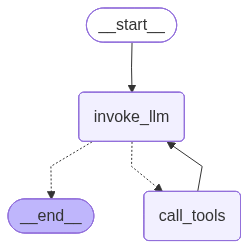

In [14]:
from IPython.display import Image, display

try:
    # We use the Mermaid graphing utility to render the flow
    display(Image(graph.get_graph().draw_mermaid_png()))

except Exception:
    # This serves as a fallback if the required dependencies aren't in the environment
    print("Graph visualization requires 'pygraphviz' or 'mermaid'. Skipping visual...")
